<a href="https://colab.research.google.com/github/shinusura86/Machine-Learning/blob/main/Machine%20Learning%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np

In [12]:
df = pd.read_csv("electric_vehicles_spec_2025.csv.csv")

# View first 5 rows
print(df.head())

    brand                model  top_speed_kmh  battery_capacity_kWh  \
0  Abarth     500e Convertible            155                  37.8   
1  Abarth       500e Hatchback            155                  37.8   
2  Abarth  600e Scorpionissima            200                  50.8   
3  Abarth         600e Turismo            200                  50.8   
4  Aiways                   U5            150                  60.0   

  battery_type  number_of_cells  torque_nm  efficiency_wh_per_km  range_km  \
0  Lithium-ion            192.0      235.0                   156       225   
1  Lithium-ion            192.0      235.0                   149       225   
2  Lithium-ion            102.0      345.0                   158       280   
3  Lithium-ion            102.0      345.0                   158       280   
4  Lithium-ion              NaN      310.0                   156       315   

   acceleration_0_100_s  ...  towing_capacity_kg cargo_volume_l  seats  \
0                   7.0  ...  

In [13]:
print(df.info())       # Data types & null values
print(df.describe())   # Statistical summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand                      478 non-null    object 
 1   model                      477 non-null    object 
 2   top_speed_kmh              478 non-null    int64  
 3   battery_capacity_kWh       478 non-null    float64
 4   battery_type               478 non-null    object 
 5   number_of_cells            276 non-null    float64
 6   torque_nm                  471 non-null    float64
 7   efficiency_wh_per_km       478 non-null    int64  
 8   range_km                   478 non-null    int64  
 9   acceleration_0_100_s       478 non-null    float64
 10  fast_charging_power_kw_dc  477 non-null    float64
 11  fast_charge_port           477 non-null    object 
 12  towing_capacity_kg         452 non-null    float64
 13  cargo_volume_l             477 non-null    object 

In [14]:
print(df.isnull().sum())

brand                          0
model                          1
top_speed_kmh                  0
battery_capacity_kWh           0
battery_type                   0
number_of_cells              202
torque_nm                      7
efficiency_wh_per_km           0
range_km                       0
acceleration_0_100_s           0
fast_charging_power_kw_dc      1
fast_charge_port               1
towing_capacity_kg            26
cargo_volume_l                 1
seats                          0
drivetrain                     0
segment                        0
length_mm                      0
width_mm                       0
height_mm                      0
car_body_type                  0
source_url                     0
dtype: int64


In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("electric_vehicles_spec_2025.csv.csv")
correlation_matrix = df.corr(numeric_only=True)

print(correlation_matrix)

                           top_speed_kmh  battery_capacity_kWh  \
top_speed_kmh                   1.000000              0.708486   
battery_capacity_kWh            0.708486              1.000000   
number_of_cells                 0.361792              0.214515   
torque_nm                       0.805513              0.756932   
efficiency_wh_per_km            0.171242              0.383607   
range_km                        0.732130              0.880433   
acceleration_0_100_s           -0.823443             -0.643716   
fast_charging_power_kw_dc       0.771810              0.728066   
towing_capacity_kg              0.231041              0.451132   
seats                          -0.315572              0.013413   
length_mm                       0.443686              0.689293   
width_mm                        0.535850              0.731496   
height_mm                      -0.462712             -0.055999   

                           number_of_cells  torque_nm  efficiency_wh_per_km

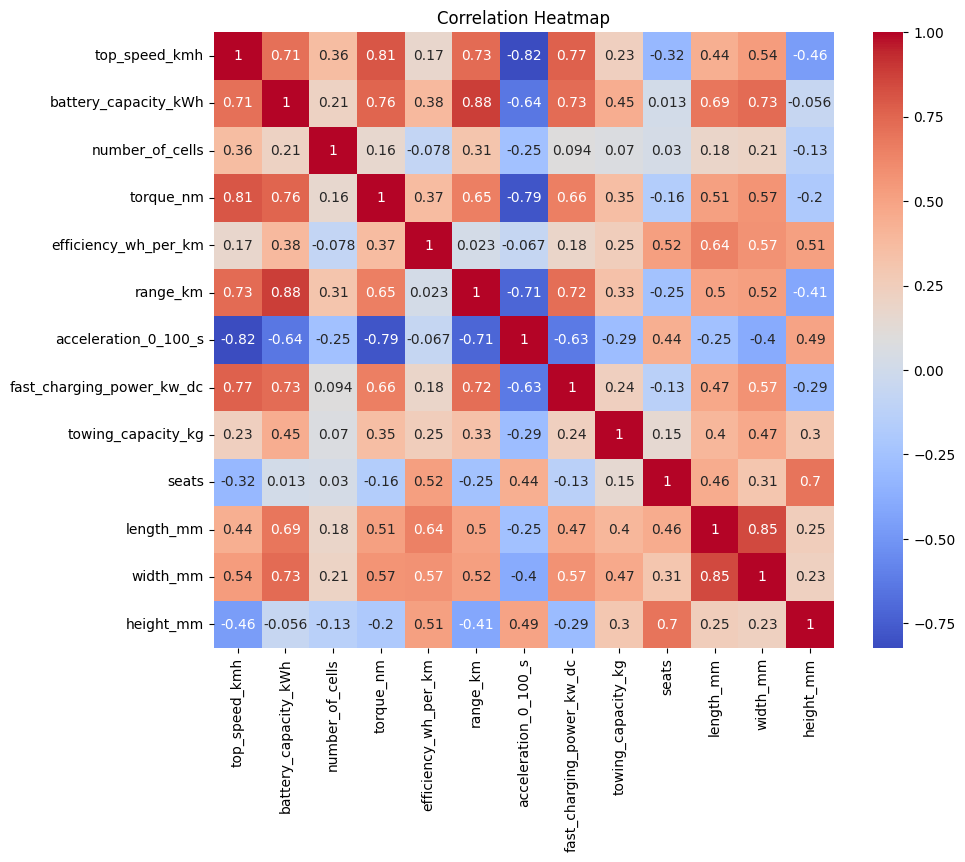

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

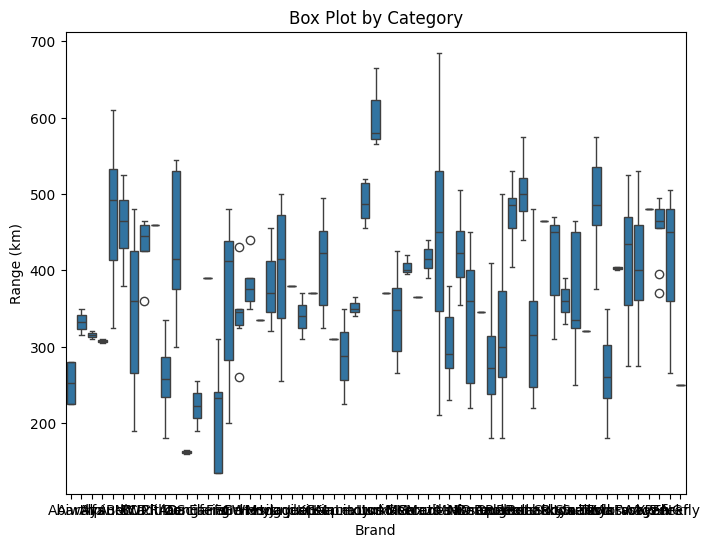

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

# Example: replace with your actual columns
sns.boxplot(x='brand', y='range_km', data=df)

plt.title("Box Plot by Category")
plt.xlabel("Brand")
plt.ylabel("Range (km)")
plt.show()

In [19]:
import pandas as pd

# Load dataset
df = pd.read_csv("electric_vehicles_spec_2025.csv.csv")

# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate IQR
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Remove outliers
df_clean = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
                (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Show result
print("Original shape:", df.shape)
print("After removing outliers:", df_clean.shape)

# Save cleaned data
df_clean.to_csv("cleaned_data.csv", index=False)

Original shape: (478, 22)
After removing outliers: (350, 22)


In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset (fix filename if needed)
df = pd.read_csv("electric_vehicles_spec_2025.csv.csv")

# Clean column names
df.columns = df.columns.str.strip()

print("Columns:", df.columns)

# 🔹 Set your target column (CHANGE if needed)
target = 'range_km'

if target not in df.columns:
    raise ValueError("Target column not found. Check column names.")

# Convert target to numeric (handles hidden strings)
df[target] = pd.to_numeric(df[target], errors='coerce')

# Drop rows with missing values
df = df.dropna()

# Split features and target
X = df.drop(columns=[target])
y = df[target]

# Convert categorical → numeric
X = pd.get_dummies(X, drop_first=True)

# Ensure all numeric
X = X.apply(pd.to_numeric, errors='coerce')

# Remove NaN / infinite values
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X = X.dropna()
y = y.loc[X.index]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create & train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("\nModel Evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# RMSE (safe version)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

print("R2 Score:", r2_score(y_test, y_pred))

Columns: Index(['brand', 'model', 'top_speed_kmh', 'battery_capacity_kWh',
       'battery_type', 'number_of_cells', 'torque_nm', 'efficiency_wh_per_km',
       'range_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc',
       'fast_charge_port', 'towing_capacity_kg', 'cargo_volume_l', 'seats',
       'drivetrain', 'segment', 'length_mm', 'width_mm', 'height_mm',
       'car_body_type', 'source_url'],
      dtype='object')

Model Evaluation:
MAE: 10.25166094839096
MSE: 165.01767053989852
RMSE: 12.845920385083295
R2 Score: 0.9824047799036008


In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("electric_vehicles_spec_2025.csv.csv")

# Clean column names
df.columns = df.columns.str.strip()

print("Columns:", df.columns)

# ✅ Correct target column
target = 'range_km'

# Convert target to numeric
df[target] = pd.to_numeric(df[target], errors='coerce')

# Drop missing values
df = df.dropna()

# 🔥 Convert target to classification (Low / High)
df[target] = pd.cut(df[target], bins=2, labels=[0, 1])

# Features and target
X = df.drop(columns=[target])
y = df[target]

# Convert categorical → numeric
X = pd.get_dummies(X, drop_first=True)

# Ensure numeric
X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna()
y = y.loc[X.index]

# Feature scaling (important)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("\nModel Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Columns: Index(['brand', 'model', 'top_speed_kmh', 'battery_capacity_kWh',
       'battery_type', 'number_of_cells', 'torque_nm', 'efficiency_wh_per_km',
       'range_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc',
       'fast_charge_port', 'towing_capacity_kg', 'cargo_volume_l', 'seats',
       'drivetrain', 'segment', 'length_mm', 'width_mm', 'height_mm',
       'car_body_type', 'source_url'],
      dtype='object')

Model Evaluation:
Accuracy: 0.9056603773584906

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.84      0.86        19
           1       0.91      0.94      0.93        34

    accuracy                           0.91        53
   macro avg       0.90      0.89      0.90        53
weighted avg       0.91      0.91      0.91        53



In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("electric_vehicles_spec_2025.csv.csv")

# Clean column names
df.columns = df.columns.str.strip()

print("Columns:", df.columns)

# ✅ Correct target column
target = 'range_km'

# Convert target to numeric
df[target] = pd.to_numeric(df[target], errors='coerce')

# Drop missing values
df = df.dropna()

# 🔥 Convert target into classes (Low / High)
df[target] = pd.cut(df[target], bins=2, labels=[0, 1])

# Split features and target
X = df.drop(columns=[target])
y = df[target]

# Convert categorical → numeric
X = pd.get_dummies(X, drop_first=True)

# Ensure numeric only
X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna()
y = y.loc[X.index]

# 🔥 Feature scaling (VERY IMPORTANT for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Create SVM model
model = SVC(kernel='rbf')   # you can also try 'linear'

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("\nModel Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Columns: Index(['brand', 'model', 'top_speed_kmh', 'battery_capacity_kWh',
       'battery_type', 'number_of_cells', 'torque_nm', 'efficiency_wh_per_km',
       'range_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc',
       'fast_charge_port', 'towing_capacity_kg', 'cargo_volume_l', 'seats',
       'drivetrain', 'segment', 'length_mm', 'width_mm', 'height_mm',
       'car_body_type', 'source_url'],
      dtype='object')

Model Evaluation:
Accuracy: 0.9245283018867925

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.84      0.89        19
           1       0.92      0.97      0.94        34

    accuracy                           0.92        53
   macro avg       0.93      0.91      0.92        53
weighted avg       0.93      0.92      0.92        53

